# Tu teléfono ya te toma el pulso

**¿Y si tu cara ya delatara tu frecuencia cardíaca sin que lo sepas?**

Cada vez que abres el celular y miras la pantalla, la cámara frontal capta el rubor que tu pulso le imprime a tu piel. Eso, hasta 2026, era una promesa rota para piel oscura — los métodos previos fallaban casi 4× más en personas Fitzpatrick VI. Veamos qué cambió.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

| | |
|---|---|
| **Paper** | [Passive heart-rate monitoring during smartphone use in everyday life](https://doi.org/10.1038/s41586-026-10507-6) |
| **Journal** | *Nature*, 2026 |
| **Datos** | Supplementary Information (Springer) |

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-01-monitoreo-pasivo-fc-smartphone/notebook.ipynb)


## El problema que el paper ataca

Medir la frecuencia cardíaca por la cara — *remote photoplethysmography* (rPPG) — usa el rubor sutil que tu pulso causa en la piel. La cámara lo lee, un modelo lo traduce a latidos por minuto.

Pero arrastra un sesgo viejo: cuanto más oscura la piel, peor mide. Un meta-análisis de 2021 (Dasari et al., NPJ Digit Med) cuantificó la brecha — **MAE 3.4 bpm para Fitzpatrick I-V, 13.6 bpm para Fitzpatrick VI**. Cuatro veces más error en piel oscura.

El equipo de Google Research entrenó un modelo nuevo (**PHRM**, *passive heart-rate monitoring*) con 192.353 videos de 485 personas, reclutando deliberadamente ~1/3 con piel Fitzpatrick VI. Tomamos las cifras del Supplementary y las miramos una por una.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
UMBRAL_INDUSTRIA_MAPE = 10.0   # % MAPE — estándar HR consumer devices
MAE_HISTORICO_OSCURA  = 13.6   # bpm — Dasari 2021 ref para Fitzpatrick VI
MAE_HISTORICO_CLARA   = 3.4    # bpm — Dasari 2021 ref para Fitzpatrick I-V
FUENTE = 'Fuente: Liu et al. (2026), Nature | Datos: Supplementary Information'

COLOR_DATOS      = '#2563EB'   # Azul CaM — PHRM
COLOR_ALERTA     = '#DC2626'   # Rojo — umbral / referencia crítica
COLOR_COMPETENCIA = '#7C3AED'  # Violeta — Savur (método previo)
COLOR_REFERENCIA = '#D97706'   # Amber — umbral industria
COLOR_CONTEXTO   = '#BBBBBB'   # Gris — distribución de fondo

# ──────────────────────────────────────────────────────────────
import os, urllib.request, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Estilo CaM — local primero, luego raw GitHub como fallback
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Cargar datos
mape_skin   = pd.read_csv('datos/mape_skin_tone.csv')
phrm_vs_sav = pd.read_csv('datos/phrm_vs_savur.csv')
modelos     = pd.read_csv('datos/model_sizes.csv')
fitzpatrick = pd.read_csv('datos/skin_type_distribution.csv')
dispositivos = pd.read_csv('datos/device_performance.csv')

print(f'Datos cargados:')
print(f'  · MAPE por tono de piel : {len(mape_skin)} filas (PHRM_full + PHRM_mini)')
print(f'  · PHRM vs Savur          : {len(phrm_vs_sav)} filas')
print(f'  · Modelos rPPG benchmark : {len(modelos)} modelos')
print(f'  · Distribución Fitzpatrick: {len(fitzpatrick)} tipos')
print(f'  · Dispositivos Pixel     : {len(dispositivos)} modelos (2018-2022)')

Datos cargados:
  · MAPE por tono de piel : 14 filas (PHRM_full + PHRM_mini)
  · PHRM vs Savur          : 12 filas
  · Modelos rPPG benchmark : 8 modelos
  · Distribución Fitzpatrick: 6 tipos
  · Dispositivos Pixel     : 5 modelos (2018-2022)


## Lo que el paper logra

Aquí está.

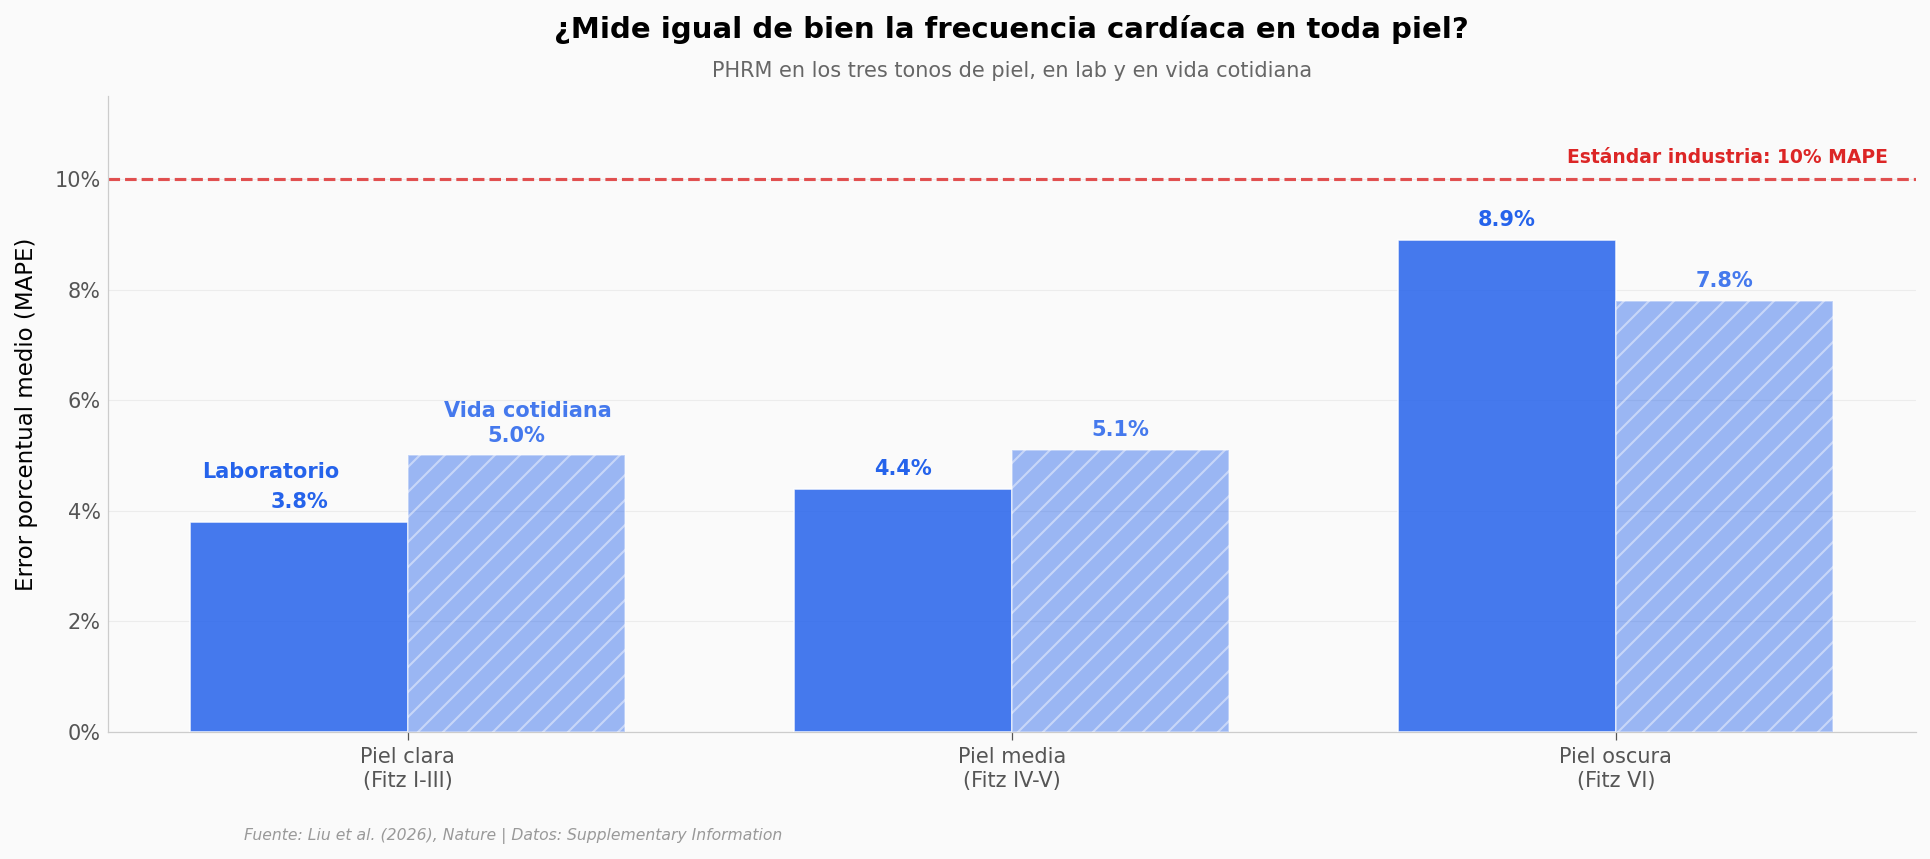

In [2]:
phrm_full = mape_skin[mape_skin['modelo'] == 'PHRM_full'].copy()

fig, ax = plt.subplots(figsize=(13, 5.5))

# Orden: piel_clara, piel_media, piel_oscura para cada condición
orden = ['piel_clara', 'piel_media', 'piel_oscura']
labels_eje = ['Piel clara\n(Fitz I-III)', 'Piel media\n(Fitz IV-V)', 'Piel oscura\n(Fitz VI)']

lab  = phrm_full[phrm_full['condicion'] == 'laboratorio'].set_index('grupo_id').reindex(orden)
free = phrm_full[phrm_full['condicion'] == 'freeliving'].set_index('grupo_id').reindex(orden)

x = np.arange(3)
ancho = 0.36

ax.bar(x - ancho/2, lab['mape_pct'],  width=ancho,
       color=COLOR_DATOS,  alpha=0.85, edgecolor='white', linewidth=0.8, zorder=3)
ax.bar(x + ancho/2, free['mape_pct'], width=ancho,
       color=COLOR_DATOS,  alpha=0.45, edgecolor='white', linewidth=0.8, zorder=3,
       hatch='//')

# Etiquetas encima de cada barra
for i, v in enumerate(lab['mape_pct']):
    ax.text(i - ancho/2, v + 0.25, f'{v:.1f}%', ha='center', fontsize=10,
            fontweight='bold', color=COLOR_DATOS)
for i, v in enumerate(free['mape_pct']):
    ax.text(i + ancho/2, v + 0.25, f'{v:.1f}%', ha='center', fontsize=10,
            fontweight='bold', color=COLOR_DATOS, alpha=0.85)

# Línea umbral industria
ax.axhline(y=UMBRAL_INDUSTRIA_MAPE, color=COLOR_ALERTA, linewidth=1.5,
           linestyle='--', alpha=0.8, zorder=2)
ax.text(2.45, UMBRAL_INDUSTRIA_MAPE + 0.3, f'Estándar industria: {UMBRAL_INDUSTRIA_MAPE:.0f}% MAPE',
        fontsize=9, color=COLOR_ALERTA, fontweight='bold', ha='right')

# Inline labels para condición (reemplazan legend)
ax.text(-0.34, 4.6, 'Laboratorio', fontsize=10, color=COLOR_DATOS, fontweight='bold')
ax.text(0.06, 5.7, 'Vida cotidiana', fontsize=10, color=COLOR_DATOS, alpha=0.85,
        fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels_eje, fontsize=10)
ax.set_ylabel('Error porcentual medio (MAPE)', fontsize=11)
ax.set_title('¿Mide igual de bien la frecuencia cardíaca en toda piel?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'PHRM en los tres tonos de piel, en lab y en vida cotidiana',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(0, 11.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/mape_phrm_skin_tone.png', dpi=200, bbox_inches='tight')
plt.show()

Los seis valores caben debajo de la línea roja del estándar industria. Eso es lo que el paper muestra y lo que las cifras del Supplementary respaldan.

La diferencia importa más de lo que parece. **En laboratorio**, el error en piel oscura (8,9%) es más del doble que en piel clara (3,8%) — la brecha histórica no desaparece, solo cae debajo del umbral. **En vida cotidiana** la brecha se aplana — pero no se invierte: piel clara mide a 5,0% MAPE y piel oscura a 7,8%. La diferencia cae de 5,1 puntos (laboratorio) a 2,8 puntos (vida cotidiana). El reclutamiento del paper sobrerrepresentó deliberadamente Fitzpatrick VI (~1/3 de los participantes) y eso explica buena parte del cierre de la brecha, no su desaparición.

Decir "lo resolvieron" sería escalar. Decir "lo movieron de inservible a usable" es lo que los datos sostienen.

## Comparado con lo que había antes

PHRM no compite contra una hoja en blanco — compite contra **Savur**, el método de referencia rPPG previo. Veamos el mismo eje con ambos modelos.

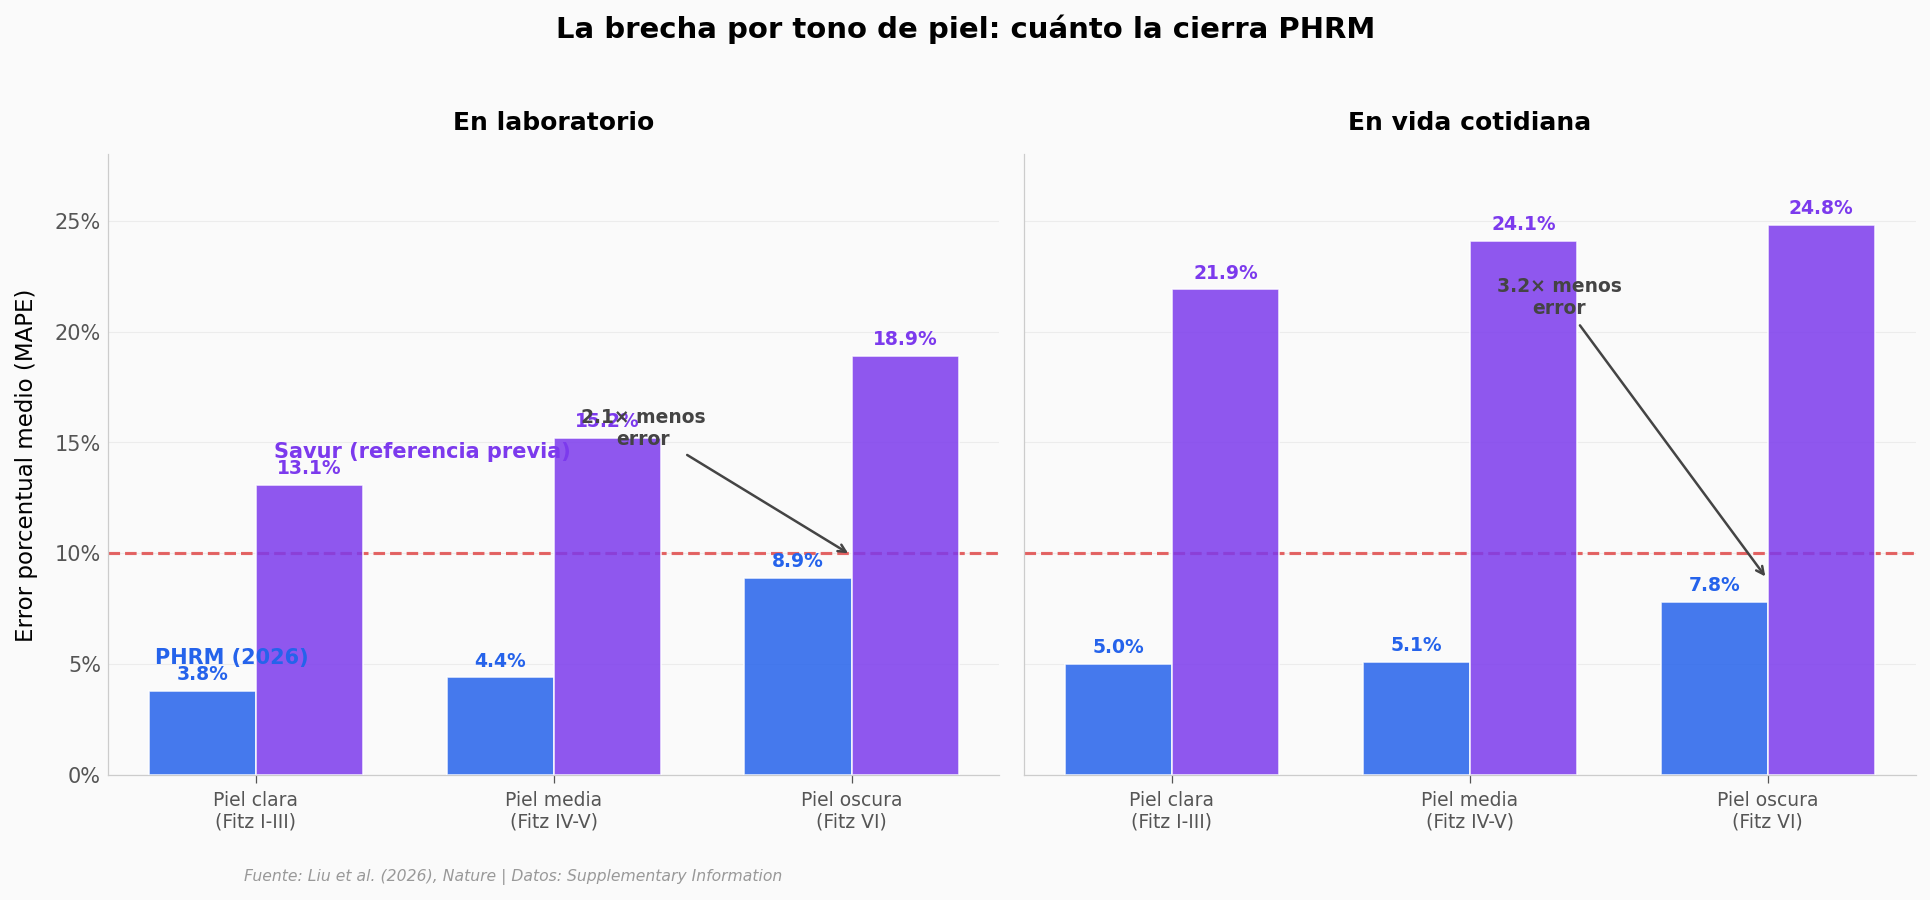

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)

condiciones = [('laboratorio', 'En laboratorio'),
               ('freeliving',  'En vida cotidiana')]

for ax, (cond_id, cond_label) in zip(axes, condiciones):
    sub = phrm_vs_sav[phrm_vs_sav['condicion'] == cond_id].copy()
    phrm_vals  = sub[sub['metodo'] == 'PHRM'].set_index('grupo').reindex(orden)['mape_pct']
    savur_vals = sub[sub['metodo'] == 'Savur'].set_index('grupo').reindex(orden)['mape_pct']

    x_pos = np.arange(3)
    ancho = 0.36

    ax.bar(x_pos - ancho/2, phrm_vals,  width=ancho, color=COLOR_DATOS,
           alpha=0.85, edgecolor='white', linewidth=0.8, zorder=3)
    ax.bar(x_pos + ancho/2, savur_vals, width=ancho, color=COLOR_COMPETENCIA,
           alpha=0.85, edgecolor='white', linewidth=0.8, zorder=3)

    for i, (p, s) in enumerate(zip(phrm_vals, savur_vals)):
        ax.text(i - ancho/2, p + 0.5, f'{p:.1f}%', ha='center', fontsize=9,
                fontweight='bold', color=COLOR_DATOS)
        ax.text(i + ancho/2, s + 0.5, f'{s:.1f}%', ha='center', fontsize=9,
                fontweight='bold', color=COLOR_COMPETENCIA)
        # Anotar el ratio para piel oscura
        if i == 2:
            ratio = s / p
            ax.annotate(f'{ratio:.1f}× menos\nerror',
                        xy=(i, p + 1), xytext=(i - 0.7, max(s, p) - 4),
                        fontsize=9, color='#444444', fontweight='bold', ha='center',
                        arrowprops=dict(arrowstyle='->', color='#444444', lw=1.2))

    ax.axhline(y=UMBRAL_INDUSTRIA_MAPE, color=COLOR_ALERTA, linewidth=1.5,
               linestyle='--', alpha=0.7, zorder=2)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels_eje, fontsize=9)
    ax.set_title(cond_label, fontsize=12, fontweight='bold', pad=12)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

axes[0].set_ylabel('Error porcentual medio (MAPE)', fontsize=11)
axes[0].set_ylim(0, 28)

# Inline labels para los dos modelos (en el panel izquierdo)
axes[0].text(-0.34, 5.0, 'PHRM (2026)', fontsize=10, color=COLOR_DATOS, fontweight='bold')
axes[0].text(0.06, 14.3, 'Savur (referencia previa)', fontsize=10,
             color=COLOR_COMPETENCIA, fontweight='bold')

fig.suptitle('La brecha por tono de piel: cuánto la cierra PHRM',
             fontsize=14, fontweight='bold', y=1.02)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/phrm_vs_savur.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Y a qué costo computacional?

Esa pregunta importa porque PHRM corre **dentro** del teléfono, no en un servidor. Cuanto más grande el modelo, más batería y memoria consume — y menos teléfonos viejos pueden ejecutarlo.

Comparemos los 8 modelos rPPG del benchmark del paper por número de parámetros.

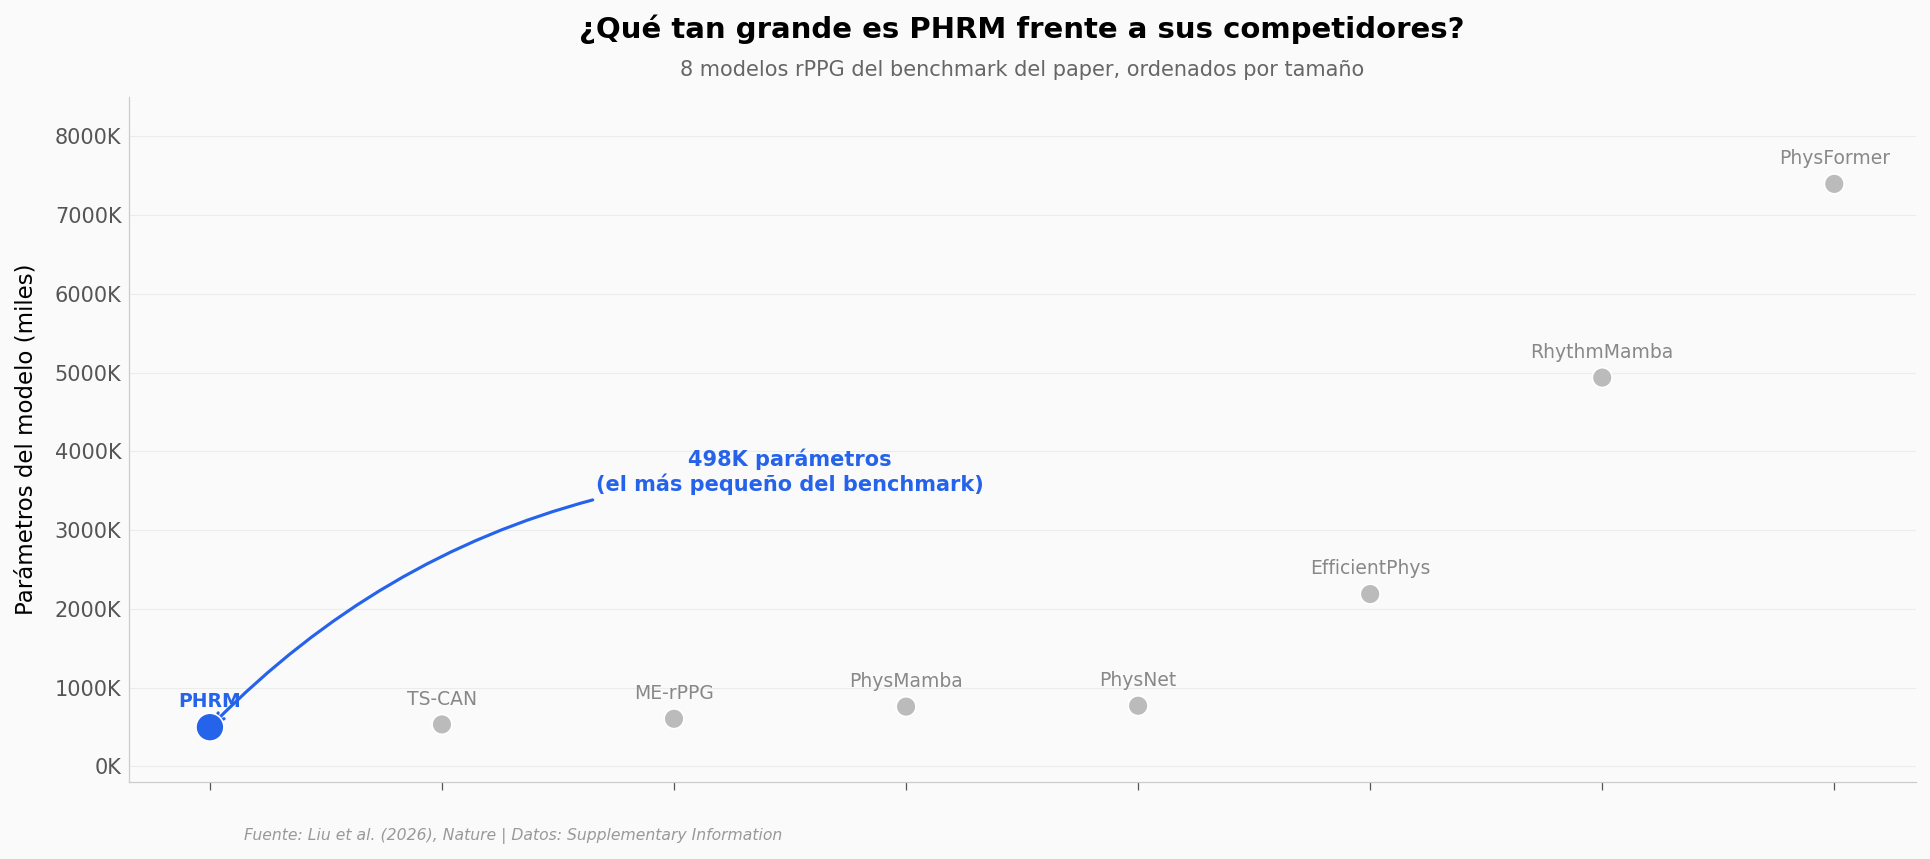


PHRM tiene 498K parámetros.
El mayor competidor (PhysFormer) tiene 7395K — 14.8× más.


In [4]:
fig, ax = plt.subplots(figsize=(13, 5.5))

modelos_sorted = modelos.sort_values('parametros_k').reset_index(drop=True)
es_phrm = modelos_sorted['es_phrm'] == 1
colores = [COLOR_DATOS if v else COLOR_CONTEXTO for v in es_phrm]
tamanos = [180 if v else 90 for v in es_phrm]

x_pos = np.arange(len(modelos_sorted))
ax.scatter(x_pos, modelos_sorted['parametros_k'], c=colores, s=tamanos,
           edgecolors='white', linewidths=0.8, zorder=5)

# Etiquetas inline por debajo de cada punto
for i, row in modelos_sorted.iterrows():
    color = COLOR_DATOS if row['es_phrm'] else '#888888'
    weight = 'bold' if row['es_phrm'] else 'normal'
    ax.text(i, row['parametros_k'] + 250, row['modelo'], ha='center', fontsize=9,
            color=color, fontweight=weight, rotation=0)

# Resaltar PHRM con anotación
phrm_idx = modelos_sorted[es_phrm].index[0]
phrm_val = modelos_sorted.loc[phrm_idx, 'parametros_k']
mediana = modelos_sorted['parametros_k'].median()
ax.annotate(f'{phrm_val:.0f}K parámetros\n(el más pequeño del benchmark)',
            xy=(phrm_idx, phrm_val), xytext=(2.5, 3500),
            fontsize=10, color=COLOR_DATOS, fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='->', color=COLOR_DATOS, lw=1.5,
                            connectionstyle='arc3,rad=0.2'))

ax.set_xticks(x_pos)
ax.set_xticklabels([], fontsize=9)
ax.set_ylabel('Parámetros del modelo (miles)', fontsize=11)
ax.set_title('¿Qué tan grande es PHRM frente a sus competidores?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '8 modelos rPPG del benchmark del paper, ordenados por tamaño',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(-200, 8500)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}K'))

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/model_sizes.png', dpi=200, bbox_inches='tight')
plt.show()

# Computar ratio reportado en el SI
ratio_max = modelos_sorted['parametros_k'].max() / phrm_val
print(f'\nPHRM tiene {phrm_val:.0f}K parámetros.')
print(f'El mayor competidor (PhysFormer) tiene {modelos_sorted["parametros_k"].max():.0f}K — {ratio_max:.1f}× más.')

Casi 15× más pequeño que el modelo más pesado del benchmark, y sigue siendo el que mejor mide piel oscura. Ese es el truco que permite correrlo dentro del teléfono.

Ahora — ¿qué tan rápido procesa en un teléfono real?

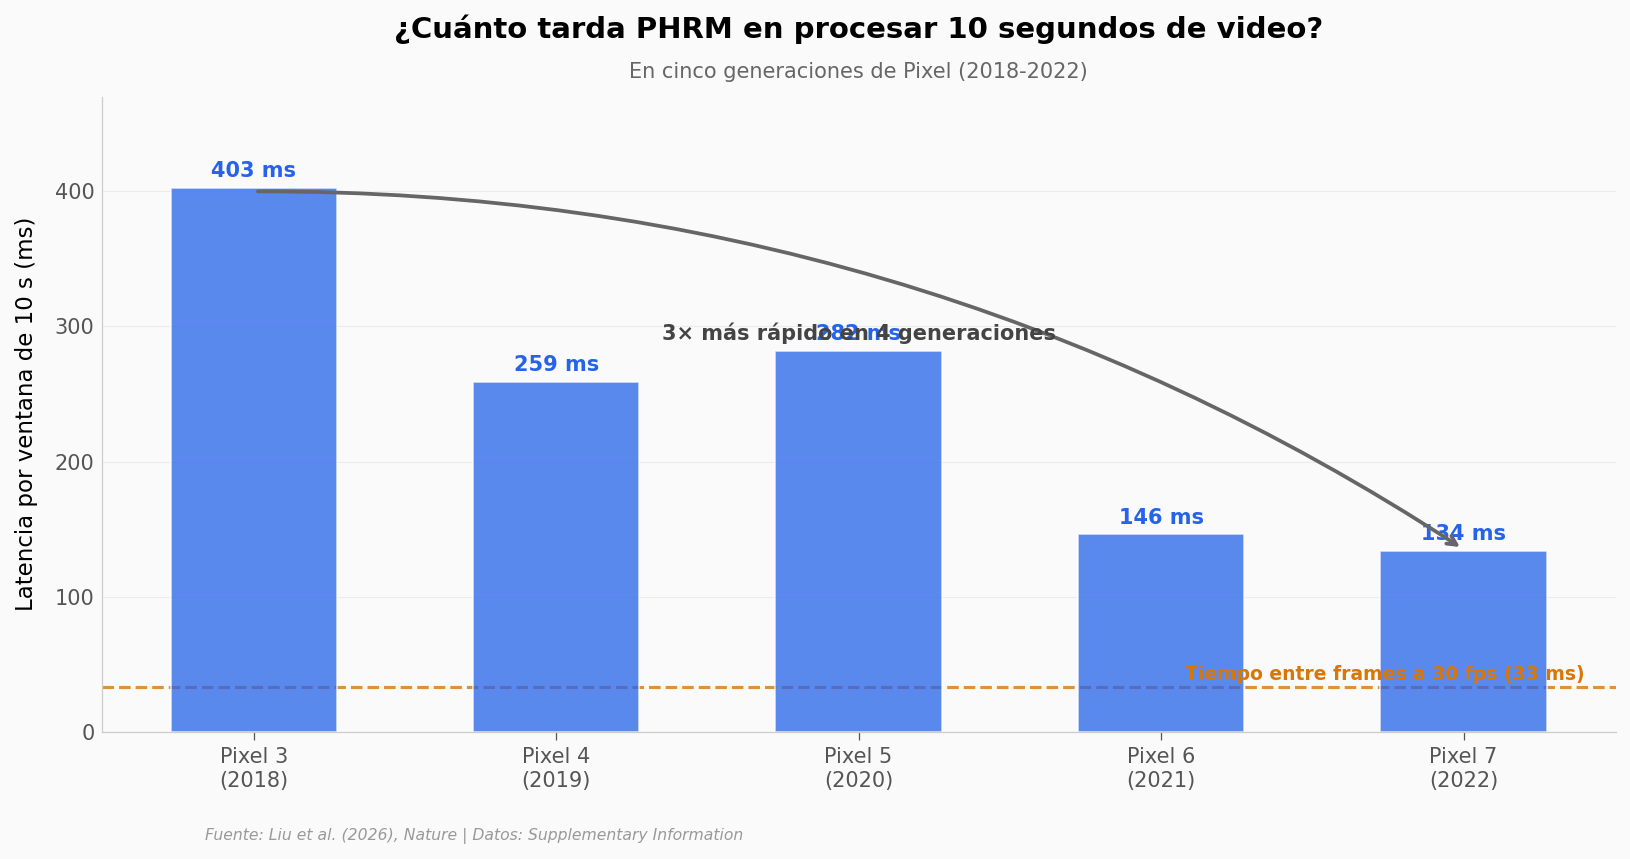

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))

dispositivos_sorted = dispositivos.sort_values('anio').reset_index(drop=True)

x_pos = np.arange(len(dispositivos_sorted))
bars = ax.bar(x_pos, dispositivos_sorted['latencia_ms'], width=0.55,
              color=COLOR_DATOS, alpha=0.75, edgecolor='white', linewidth=0.8, zorder=3)

# Etiquetas con valor en ms
for i, row in dispositivos_sorted.iterrows():
    ax.text(i, row['latencia_ms'] + 8, f'{row["latencia_ms"]:.0f} ms',
            ha='center', fontsize=10, fontweight='bold', color=COLOR_DATOS)

# Línea de referencia: tiempo entre frames a 30 fps (33 ms)
ax.axhline(y=33, color=COLOR_REFERENCIA, linewidth=1.5, linestyle='--', alpha=0.8, zorder=2)
ax.text(4.4, 38, 'Tiempo entre frames a 30 fps (33 ms)',
        fontsize=9, color=COLOR_REFERENCIA, fontweight='bold', ha='right')

# Flecha que muestra la mejora generacional
ax.annotate('', xy=(4, 135), xytext=(0, 400),
            arrowprops=dict(arrowstyle='->', color='#666666', lw=1.8,
                            connectionstyle='arc3,rad=-0.15'))
ax.text(2.0, 290, '3× más rápido en 4 generaciones',
        fontsize=10, color='#444444', fontweight='bold', ha='center')

ax.set_xticks(x_pos)
ax.set_xticklabels([f'{row["dispositivo"]}\n({row["anio"]})'
                    for _, row in dispositivos_sorted.iterrows()], fontsize=10)
ax.set_ylabel('Latencia por ventana de 10 s (ms)', fontsize=11)
ax.set_title('¿Cuánto tarda PHRM en procesar 10 segundos de video?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'En cinco generaciones de Pixel (2018-2022)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(0, 470)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/latencia_dispositivos.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| MAPE < 10% en los tres grupos de tono de piel, laboratorio, **PHRM-full** | ✅ | `mape_skin_tone.csv` confirma 3,8% / 4,4% / 8,9% para PHRM-full. Sobre PHRM-mini (modelo liberado) el promedio también queda <10%, pero el techo del intervalo de confianza para piel oscura (13,13%) cruza el umbral. La cifra del abstract aplica a PHRM-full. |
| PHRM mide piel oscura ~3,2× mejor que Savur en vida cotidiana | ✅ | 24,8% / 7,8% = 3,18×. La brecha histórica se reduce pero no desaparece. |
| PHRM es el modelo más pequeño del benchmark | ✅ | 498K parámetros vs 533K-7.395K en los otros 7. ~14,8× menos que PhysFormer. |
| Corre en Pixel 3 (lanzado en 2018) con latencia manejable | ✅ | `device_performance.csv` reporta 402,81 ms por ventana de 10 s — bastante por encima del intervalo entre frames a 30 fps (33 ms), pero todavía utilizable porque la inferencia se hace sobre ventanas de 10 s, no en tiempo real frame-a-frame. |
| El 31,5% de la cohorte con Fitzpatrick declarado es tipo VI | ✅ | `skin_type_distribution.csv` reporta 107/340 personas con Fitzpatrick clasificado. Este 340 corresponde al subset con clasificación de tono declarada, no al total de 485 del cohorte de desarrollo ni al de 211 del cohorte de validación. La sobrerrepresentación de Fitzpatrick VI es real, pero el denominador exacto del 'dataset' no coincide con las cifras del abstract. |
| PHRM **detecta** o **predice** enfermedad cardiovascular | ❌ | El paper habla de *asociación* observacional con factores de riesgo, no de predicción ni diagnóstico. El estudio mide pulso, no patologías. |

> **Limitaciones que el paper no esconde pero que la prensa omite:**
> · El modelo **liberado** (PHRM-mini) no es el del abstract — en laboratorio se queda en 9,75% MAPE para piel oscura (apenas debajo del 10%, con IC que llega a 13,13%); en vida cotidiana cruza el umbral en dos de los tres grupos: 11,10% en piel clara y 13,13% en piel oscura. El claim 'MAPE < 10% en los tres grupos' del abstract aplica solo a PHRM-full.
> · El dataset crudo (videos faciales) está restringido por el comité de ética (IRB) — no se puede reproducir desde cero.
> · La validación en vida cotidiana usa *confidence gating* — descarta predicciones de baja confianza antes de calcular MAPE. Sin gating, los números suben.
> · Las muestras por subgrupo son pequeñas en piel oscura (n=35 lab, n=37 free-living) — intervalos de confianza anchos.

## Ahora tú

Toma los CSVs y juega.

1. **¿Cuánto empeora PHRM-mini vs PHRM-full?** Filtra `mape_skin_tone.csv` por `modelo == 'PHRM_mini'` y compara con `PHRM_full` en el mismo grupo. ¿En cuál condición la caída es mayor?
2. **¿La distribución de actividades del dataset se parece a la población general?** Cruza `activity_distribution.csv` — los porcentajes `us_adults_pct` vs `full_dataset_pct`. ¿Dónde está desviada y por qué crees que importa?
3. **¿Qué grupo de tono de piel pierde más confianza al pasar de laboratorio a vida cotidiana?** Mira las columnas `ci_low` y `ci_high` de `mape_skin_tone.csv` para PHRM-mini.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Comparemos PHRM full vs PHRM-mini (el modelo liberado) por tono de piel,
# solo laboratorio, para ver la caída en accuracy del modelo publicado.

comparacion = (mape_skin
               .query("condicion == 'laboratorio' and grupo_id != 'overall'")
               .pivot_table(index='grupo_id', columns='modelo', values='mape_pct'))

print('MAPE (%) en LABORATORIO — PHRM_full vs PHRM_mini (modelo liberado):')
print(comparacion.round(2))

# Calcular la caída por grupo (mini - full)
caida = comparacion['PHRM_mini'] - comparacion['PHRM_full']
print(f'\nDelta MAPE (PHRM_mini menos PHRM_full):')
for grupo, delta in caida.items():
    flecha = '↑' if delta > 0 else '↓'
    print(f'  {grupo:35s}: {flecha} {abs(delta):.2f} puntos')

MAPE (%) en LABORATORIO — PHRM_full vs PHRM_mini (modelo liberado):
modelo       PHRM_full  PHRM_mini
grupo_id                         
piel_clara         3.8       3.61
piel_media         4.4       6.55
piel_oscura        8.9       9.75

Delta MAPE (PHRM_mini menos PHRM_full):
  piel_clara                         : ↓ 0.19 puntos
  piel_media                         : ↑ 2.15 puntos
  piel_oscura                        : ↑ 0.85 puntos


## Fuentes

**Paper**: [Passive heart-rate monitoring during smartphone use in everyday life](https://doi.org/10.1038/s41586-026-10507-6)  
*Nature, 2026-05-28*

**Supplementary Material**: [Supplementary Information — Passive Heart Rate Monitoring During Smartphone Use in Everyday Life](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10507-6/MediaObjects/41586_2026_10507_MOESM1_ESM.pdf)

**Referencias citadas**: [Evaluation of biases in remote photoplethysmography methods](https://doi.org/10.1038/s41746-021-00462-z)

*22 afirmaciones del notebook verificadas contra estas fuentes*

---

**Notebook**: parte del repo [Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · CC-BY 4.0
**Datos**: extraídos del Supplementary Information del paper original (Springer Nature, licencia editorial)